In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

print("All imports successful ✓")


All imports successful ✓


In [3]:
dataset_path = "../datasets"

data = []
for filename in os.listdir(dataset_path):
    if filename.endswith(".jpg"):
        parts = filename.split("_")
        if len(parts) >= 3:
            try:
                age = int(parts[0])
                gender = int(parts[1])
                data.append({
                    "filename": filename,
                    "age": age,
                    "gender": gender
                })
            except:
                pass  # skip bad filenames

df = pd.DataFrame(data)
print(f"Total images loaded: {len(df)}")
df.head(10)

Total images loaded: 23709


,filename,age,gender
0,100_0_0_20170112213500903.jpg.chip.jpg,100,0
1,100_0_0_20170112215240346.jpg.chip.jpg,100,0
2,100_1_0_20170110183726390.jpg.chip.jpg,100,1
3,100_1_0_20170112213001988.jpg.chip.jpg,100,1
4,100_1_0_20170112213303693.jpg.chip.jpg,100,1
5,100_1_0_20170112215032192.jpg.chip.jpg,100,1
6,100_1_0_20170117195420803.jpg.chip.jpg,100,1
7,100_1_0_20170119212053665.jpg.chip.jpg,100,1
8,100_1_2_20170105174847679.jpg.chip.jpg,100,1
9,100_1_2_20170112213615815.jpg.chip.jpg,100,1


In [4]:
print("Dataset Summary")
print("---------------")
print(f"Total images   : {len(df)}")
print(f"Age range      : {df['age'].min()} to {df['age'].max()} years")
print(f"Male images    : {(df['gender'] == 0).sum()}")
print(f"Female images  : {(df['gender'] == 1).sum()}")

Dataset Summary
---------------
Total images   : 23709
Age range      : 1 to 116 years
Male images    : 12391
Female images  : 11317


In [5]:
def get_age_group(age):
    if age <= 12:   return "Child (0-12)"
    elif age <= 19: return "Teen (13-19)"
    elif age <= 35: return "Young Adult (20-35)"
    elif age <= 55: return "Adult (36-55)"
    else:           return "Senior (56+)"

df["age_group"] = df["age"].apply(get_age_group)
print(df["age_group"].value_counts())

age_group
Young Adult (20-35)    10514
Adult (36-55)           5225
Child (0-12)            3413
Senior (56+)            3377
Teen (13-19)            1180
Name: count, dtype: int64


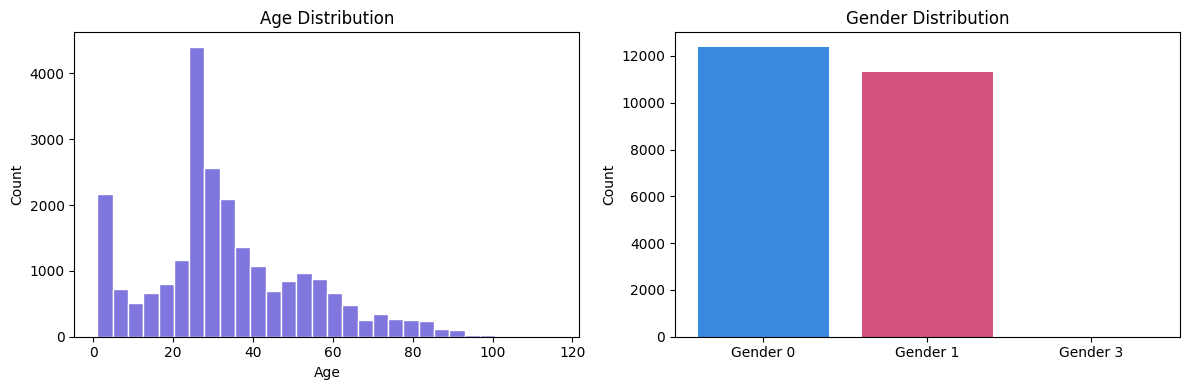

Chart saved ✓
Gender value counts: {0: 12391, 1: 11317, 3: 1}


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Age distribution
axes[0].hist(df["age"], bins=30, color="#7F77DD", edgecolor="white")
axes[0].set_title("Age Distribution")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

# Gender distribution - safe version
gender_counts = df["gender"].value_counts().sort_index()
labels = [f"Gender {i}" for i in gender_counts.index]
colors = ["#378ADD", "#D4537E", "#44AA77", "#FF8C00"]
axes[1].bar(labels, gender_counts.values, color=colors[:len(labels)])
axes[1].set_title("Gender Distribution")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("../dataset_distribution.png")
plt.show()
print("Chart saved ✓")
print("Gender value counts:", gender_counts.to_dict())

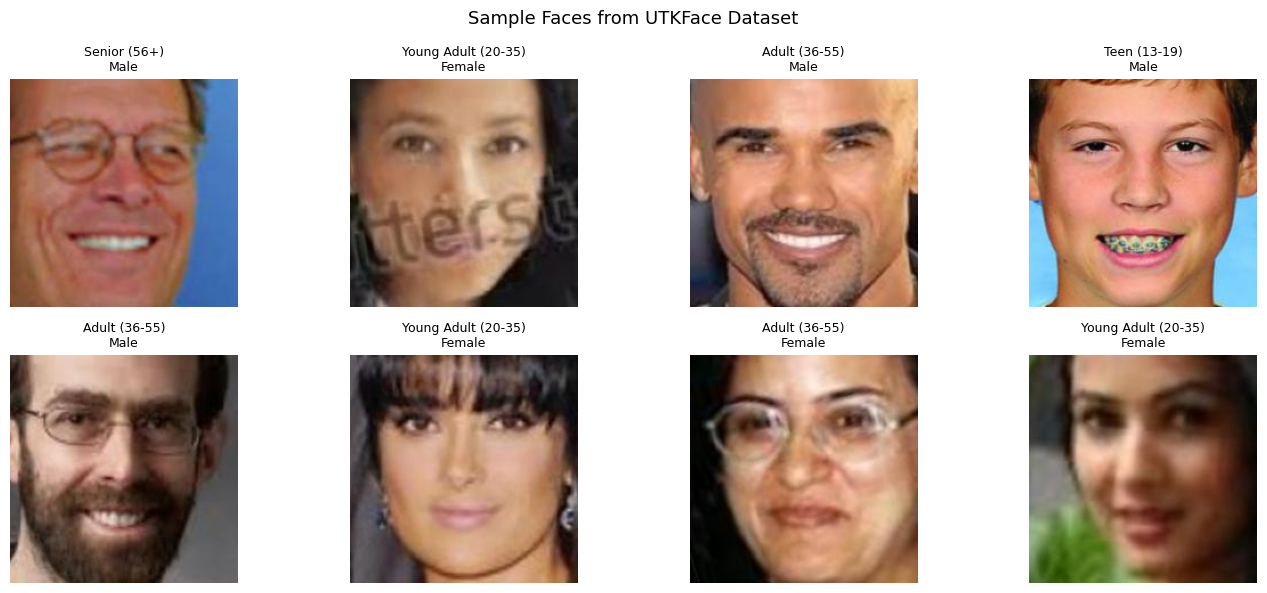

In [8]:
sample = df.sample(8)
fig, axes = plt.subplots(2, 4, figsize=(14, 6))

for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img = Image.open(os.path.join(dataset_path, row["filename"]))
    ax.imshow(img)
    ax.set_title(f"{row['age_group']}\n{'Male' if row['gender']==0 else 'Female'}", fontsize=9)
    ax.axis("off")

plt.suptitle("Sample Faces from UTKFace Dataset", fontsize=13)
plt.tight_layout()
plt.show()